In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

standing_result = pd.read_csv('standing_result.csv')
lying_result = pd.read_csv('lying_chest_result.csv')
paseo_1s = pd.read_csv('indicadores_1s_paseo.csv')

standing_result.head()

,id,dispositivo_id,timestamp,n_muestras,actividad,vedba_media,vedba_max,pitch_medio,roll_medio,sector_raw_id,medicion_rapida_id,comportamiento_predicho
0,1,4,2026-08-29 16:36:12.960 +0200,13,0,0.023770,0.048503,-9.633835,-0.852134,37,1,Standing
1,2,4,2026-08-29 16:36:13.960 +0200,12,0,0.048313,0.073888,-10.104003,-0.248516,37,14,Standing
2,3,4,2026-08-29 16:36:14.960 +0200,13,0,0.039889,0.065630,-10.611147,1.384886,37,26,Standing
3,4,4,2026-08-29 16:36:15.960 +0200,12,0,0.030733,0.050010,-11.040542,3.219994,37,39,Standing
4,5,4,2026-08-29 16:36:16.960 +0200,13,0,0.048248,0.078601,-11.347333,3.566389,37,51,Standing


In [4]:
def resumen_accuracy(df, etiqueta_real, nombre_fichero):
    n_total = len(df)
    conteo = df['comportamiento_predicho'].value_counts()
    n_aciertos = conteo.get(etiqueta_real, 0)
    accuracy = n_aciertos / n_total * 100

    print(f"{nombre_fichero} (etiqueta real: {etiqueta_real})")
    print(f"n = {n_total}, aciertos = {n_aciertos} ({accuracy:.1f}%)")
    print("Distribución de predicciones:")
    print(conteo)
    print()

resumen_accuracy(standing_result, 'Standing', 'standing_result')
resumen_accuracy(lying_result, 'Lying chest', 'lying_chest_result')

standing_result (etiqueta real: Standing)
n = 105, aciertos = 105 (100.0%)
Distribución de predicciones:
comportamiento_predicho
Standing    105
Name: count, dtype: int64

lying_chest_result (etiqueta real: Lying chest)
n = 131, aciertos = 130 (99.2%)
Distribución de predicciones:
comportamiento_predicho
Lying chest    130
Walking          1
Name: count, dtype: int64



In [ ]:
# Vemos como están distribuidos los datos del paseo

paseo_1s['timestamp'] = pd.to_datetime(paseo_1s['timestamp'])
paseo_1s = paseo_1s.sort_values('timestamp').reset_index(drop=True)

print(f"Rango completo: {paseo_1s['timestamp'].min()} a {paseo_1s['timestamp'].max()}")
print(f"Duración total: {(paseo_1s['timestamp'].max() - paseo_1s['timestamp'].min())}")

paseo_1s[['timestamp', 'vedba_media', 'vedba_max', 'pitch_medio', 'roll_medio', 'comportamiento_predicho']].head()

Rango completo: 2026-08-30 11:50:50.960000+02:00 a 2026-08-30 12:26:52.960000+02:00
Duración total: 0 days 00:36:02


,timestamp,vedba_media,vedba_max,pitch_medio,roll_medio,comportamiento_predicho
0,2026-08-30 11:50:50.960000+02:00,0.006822,0.014900,6.070680,1.995578,Standing
1,2026-08-30 11:50:51.960000+02:00,0.007686,0.012042,6.090584,2.036163,Standing
2,2026-08-30 11:50:52.960000+02:00,0.009873,0.017507,6.047946,2.161776,Standing
3,2026-08-30 11:50:53.960000+02:00,0.009394,0.022901,6.012150,2.212923,Standing
4,2026-08-30 11:50:54.960000+02:00,0.008316,0.015332,6.072084,2.070581,Standing


In [ ]:
# Se mira como están distribuidos los datos en el tramo de 5 minutos grabado

inicio = pd.Timestamp('2026-08-30 12:14:05', tz='+02:00')
fin = inicio + pd.Timedelta(minutes=5)

paseo_5min = paseo_1s[(paseo_1s['timestamp'] >= inicio) & (paseo_1s['timestamp'] < fin)].reset_index(drop=True)

print(f"Filas en el tramo: {len(paseo_5min)}")
print(f"Rango real: {paseo_5min['timestamp'].min()} a {paseo_5min['timestamp'].max()}")
paseo_5min['comportamiento_predicho'].value_counts()

Filas en el tramo: 296
Rango real: 2026-08-30 12:14:05.960000+02:00 a 2026-08-30 12:19:04.960000+02:00


comportamiento_predicho
Walking        138
Trotting       125
Lying chest     22
Standing        11
Name: count, dtype: int64

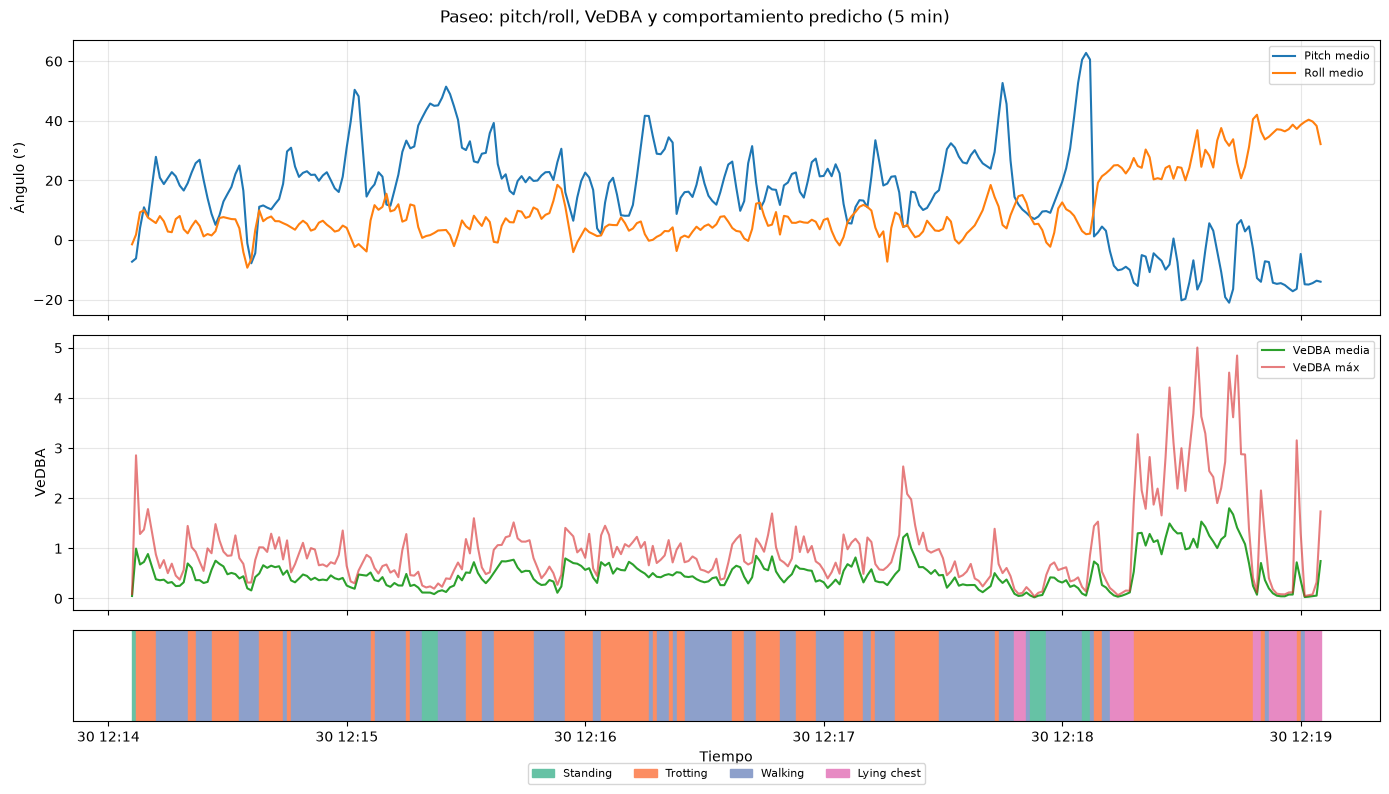

In [7]:
# Antes de comparar con los datos reales, se grafica los resultados obtenidos por el modelo, asi como las metricas utilizadas para la predicción de comportamiento

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 3, 1]})

t = paseo_5min['timestamp']

# Panel 1: pitch y roll
ax1.plot(t, paseo_5min['pitch_medio'], label='Pitch medio', color='tab:blue')
ax1.plot(t, paseo_5min['roll_medio'], label='Roll medio', color='tab:orange')
ax1.set_ylabel('Ángulo (°)')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)

# Panel 2: VeDBA media y máxima
ax2.plot(t, paseo_5min['vedba_media'], label='VeDBA media', color='tab:green')
ax2.plot(t, paseo_5min['vedba_max'], label='VeDBA máx', color='tab:red', alpha=0.6)
ax2.set_ylabel('VeDBA')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(alpha=0.3)

# Panel 3: banda de comportamiento predicho, coloreada por clase
clases = paseo_5min['comportamiento_predicho'].unique()
colores_clase = dict(zip(clases, plt.cm.Set2.colors))

for i in range(len(paseo_5min) - 1):
    clase = paseo_5min['comportamiento_predicho'].iloc[i]
    ax3.axvspan(t.iloc[i], t.iloc[i + 1], color=colores_clase[clase])

# Leyenda manual para la banda de colores
from matplotlib.patches import Patch
leyenda = [Patch(color=colores_clase[c], label=c) for c in clases]
ax3.legend(handles=leyenda, loc='upper center', bbox_to_anchor=(0.5, -0.4), ncol=len(clases), fontsize=8)
ax3.set_yticks([])
ax3.set_xlabel('Tiempo')

fig.suptitle('Paseo: pitch/roll, VeDBA y comportamiento predicho (5 min)')
plt.tight_layout()
plt.show()

In [10]:
import datetime

anotacion = pd.read_excel('referencia_video.xlsx')  # columnas: inicio, comportamiento_real
anotacion = anotacion.sort_values('inicio').reset_index(drop=True)

fecha_ensayo = pd.Timestamp('2026-08-30')

def a_datetime(valor, fecha_base):
    if isinstance(valor, datetime.time):
        t = valor
    else:
        t = pd.to_datetime(str(valor).strip()).time()
    return fecha_base + pd.Timedelta(hours=t.hour, minutes=t.minute, seconds=t.second)

anotacion['inicio'] = anotacion['inicio'].apply(lambda v: a_datetime(v, fecha_ensayo))
anotacion['inicio'] = anotacion['inicio'].dt.tz_localize('+02:00')

# El fin de cada tramo es el inicio del siguiente; el último tramo se cierra con el final de la ventana de 5 minutos
anotacion['fin'] = anotacion['inicio'].shift(-1)
anotacion.loc[anotacion.index[-1], 'fin'] = paseo_5min['timestamp'].max() + pd.Timedelta(seconds=1)

anotacion

,inicio,comportamiento_real,fin
0,2026-08-30 12:14:05+02:00,Standing,2026-08-30 12:14:06+02:00
1,2026-08-30 12:14:06+02:00,Trotting,2026-08-30 12:14:11+02:00
2,2026-08-30 12:14:11+02:00,Walking,2026-08-30 12:14:19+02:00
3,2026-08-30 12:14:19+02:00,Trotting,2026-08-30 12:14:22+02:00
4,2026-08-30 12:14:22+02:00,Standing,2026-08-30 12:14:25+02:00
5,2026-08-30 12:14:25+02:00,Trotting,2026-08-30 12:14:32+02:00
6,2026-08-30 12:14:32+02:00,Standing,2026-08-30 12:14:35+02:00
7,2026-08-30 12:14:35+02:00,Trotting,2026-08-30 12:14:45+02:00
8,2026-08-30 12:14:45+02:00,Walking,2026-08-30 12:14:58+02:00
9,2026-08-30 12:14:58+02:00,Standing,2026-08-30 12:15:03+02:00


In [11]:
# Se expande a 1 s porque el excel marca tramos de inicio

filas_expandido = []
for _, tramo in anotacion.iterrows():
    segundos = pd.date_range(tramo['inicio'], tramo['fin'], freq='1s', inclusive='left')
    for s in segundos:
        filas_expandido.append({'timestamp': s, 'comportamiento_real': tramo['comportamiento_real']})

anotacion_expandida = pd.DataFrame(filas_expandido)
print(f"Segundos anotados: {len(anotacion_expandida)}")
anotacion_expandida.head()

Segundos anotados: 301


,timestamp,comportamiento_real
0,2026-08-30 12:14:05+02:00,Standing
1,2026-08-30 12:14:06+02:00,Trotting
2,2026-08-30 12:14:07+02:00,Trotting
3,2026-08-30 12:14:08+02:00,Trotting
4,2026-08-30 12:14:09+02:00,Trotting


In [ ]:
# Se redondea el timestamp de paseo_5min al segundo, para que coincida exactamente con los segundos "en punto" de anotacion_expandida
paseo_5min['timestamp_seg'] = paseo_5min['timestamp'].dt.floor('s')

comparacion = paseo_5min.merge(
    anotacion_expandida,
    left_on='timestamp_seg', right_on='timestamp',
    how='inner', suffixes=('', '_anotacion'),
)

print(f"Segundos comparados: {len(comparacion)} (de {len(paseo_5min)} predichos y {len(anotacion_expandida)} anotados)")
comparacion[['timestamp_seg', 'comportamiento_predicho', 'comportamiento_real']].head(10)

Segundos comparados: 296 (de 296 predichos y 301 anotados)


,timestamp_seg,comportamiento_predicho,comportamiento_real
0,2026-08-30 12:14:05+02:00,Standing,Standing
1,2026-08-30 12:14:06+02:00,Trotting,Trotting
2,2026-08-30 12:14:07+02:00,Trotting,Trotting
3,2026-08-30 12:14:08+02:00,Trotting,Trotting
4,2026-08-30 12:14:09+02:00,Trotting,Trotting
5,2026-08-30 12:14:11+02:00,Walking,Walking
6,2026-08-30 12:14:12+02:00,Walking,Walking
7,2026-08-30 12:14:13+02:00,Walking,Walking
8,2026-08-30 12:14:14+02:00,Walking,Walking
9,2026-08-30 12:14:15+02:00,Walking,Walking


In [13]:
matriz = pd.crosstab(comparacion['comportamiento_real'], comparacion['comportamiento_predicho'], rownames=['Real'], colnames=['Predicho'])
matriz

Predicho,Lying chest,Standing,Trotting,Walking
Real,,,,
Standing,22,11,5,45
Trotting,0,0,110,14
Walking,0,0,10,79


In [14]:
accuracy_global = (comparacion['comportamiento_real'] == comparacion['comportamiento_predicho']).mean() * 100
print(f"Accuracy global: {accuracy_global:.1f}%\n")

for clase in sorted(comparacion['comportamiento_real'].unique()):
    sub = comparacion[comparacion['comportamiento_real'] == clase]
    acc_clase = (sub['comportamiento_real'] == sub['comportamiento_predicho']).mean() * 100
    print(f"{clase}: n={len(sub)}, accuracy={acc_clase:.1f}%")

Accuracy global: 67.6%

Standing: n=83, accuracy=13.3%
Trotting: n=124, accuracy=88.7%
Walking: n=89, accuracy=88.8%


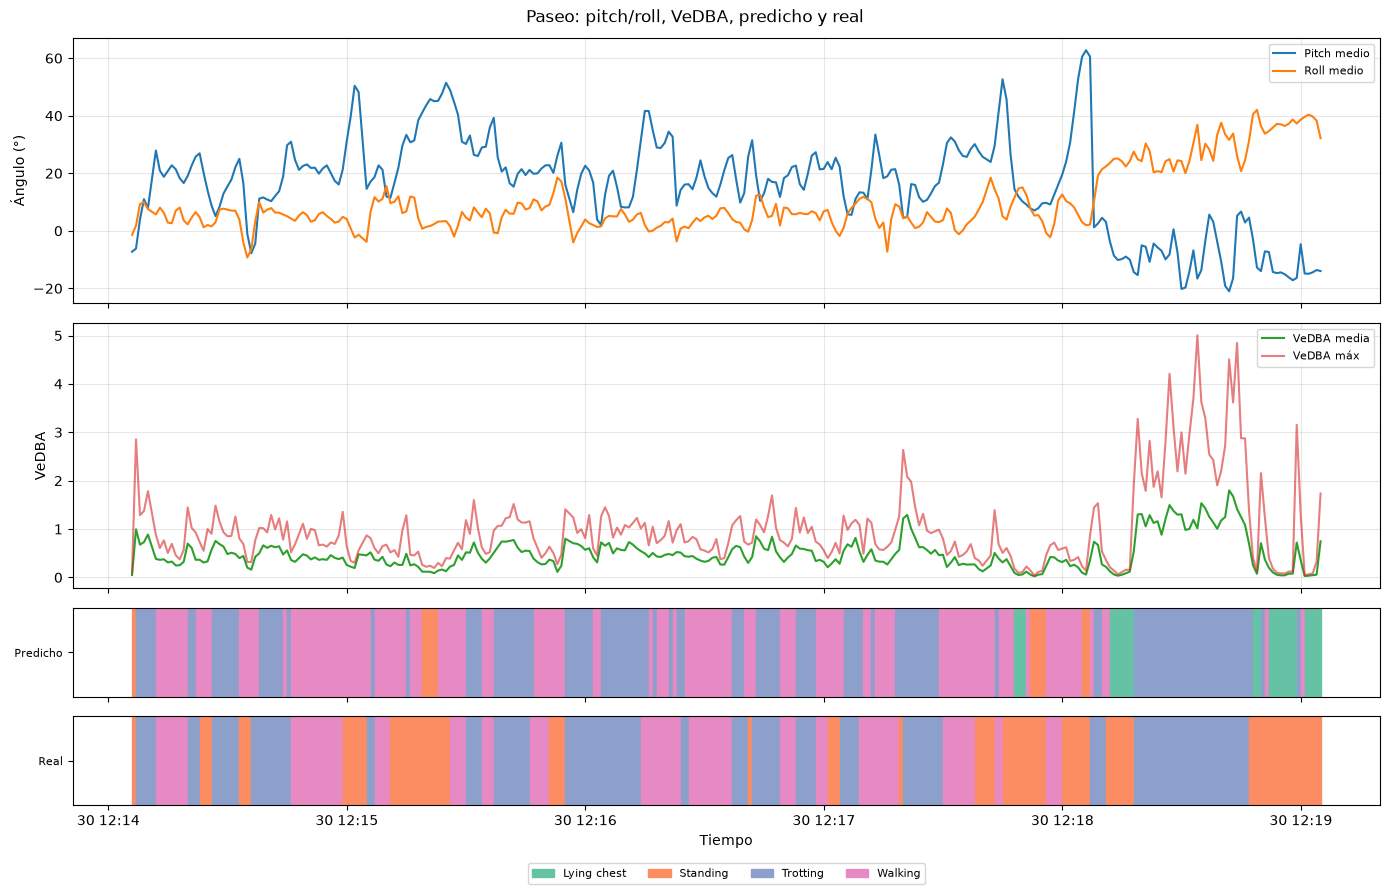

In [ ]:
comparacion = paseo_5min.merge(
    anotacion_expandida, left_on='timestamp_seg', right_on='timestamp',
    how='left', suffixes=('', '_anotacion'),
)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 9), sharex=True, gridspec_kw={'height_ratios': [3, 3, 1, 1]})

t = comparacion['timestamp']

ax1.plot(t, comparacion['pitch_medio'], label='Pitch medio', color='tab:blue')
ax1.plot(t, comparacion['roll_medio'], label='Roll medio', color='tab:orange')
ax1.set_ylabel('Ángulo (°)')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(t, comparacion['vedba_media'], label='VeDBA media', color='tab:green')
ax2.plot(t, comparacion['vedba_max'], label='VeDBA máx', color='tab:red', alpha=0.6)
ax2.set_ylabel('VeDBA')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(alpha=0.3)

clases = sorted(set(comparacion['comportamiento_predicho'].dropna()) |
                 set(comparacion['comportamiento_real'].dropna()))
colores_clase = dict(zip(clases, plt.cm.Set2.colors))

def pintar_banda(ax, columna, etiqueta_eje):
    for i in range(len(comparacion) - 1):
        clase = comparacion[columna].iloc[i]
        if pd.notna(clase):
            ax.axvspan(t.iloc[i], t.iloc[i + 1], color=colores_clase[clase])
    ax.set_yticks([0.5])
    ax.set_yticklabels([etiqueta_eje], fontsize=8)

pintar_banda(ax3, 'comportamiento_predicho', 'Predicho')
pintar_banda(ax4, 'comportamiento_real', 'Real')

from matplotlib.patches import Patch
leyenda = [Patch(color=colores_clase[c], label=c) for c in clases]
ax4.legend(handles=leyenda, loc='upper center', bbox_to_anchor=(0.5, -0.6), ncol=len(clases), fontsize=8)
ax4.set_xlabel('Tiempo')

fig.suptitle('Paseo: pitch/roll, VeDBA, predicho y real')
plt.tight_layout()
plt.show()

In [16]:
matriz_alineada = pd.crosstab(
    comparacion['comportamiento_real'], comparacion['comportamiento_predicho'],
    rownames=['Real'], colnames=['Predicho'], dropna=True,
)
print(matriz_alineada)

comp_validas = comparacion.dropna(subset=['comportamiento_real', 'comportamiento_predicho'])
accuracy_global = (comp_validas['comportamiento_real'] == comp_validas['comportamiento_predicho']).mean() * 100
print(f"\nAccuracy global: {accuracy_global:.1f}% (n={len(comp_validas)})")

for clase in sorted(comp_validas['comportamiento_real'].unique()):
    sub = comp_validas[comp_validas['comportamiento_real'] == clase]
    acc_clase = (sub['comportamiento_real'] == sub['comportamiento_predicho']).mean() * 100
    print(f"{clase}: n={len(sub)}, accuracy={acc_clase:.1f}%")

Predicho  Lying chest  Standing  Trotting  Walking
Real                                              
Standing           22        11         5       45
Trotting            0         0       110       14
Walking             0         0        10       79

Accuracy global: 67.6% (n=296)
Standing: n=83, accuracy=13.3%
Trotting: n=124, accuracy=88.7%
Walking: n=89, accuracy=88.8%
